## Building a Hybrid Pipeline (Statistical + ML + DL)

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# Load the CSV file into a DataFrame

df = pd.read_csv('finalNew.csv')

# View the first 5 rows
print(df.head())
df

       Date_x      Close       High        Low       Open     Volume  \
0  2023-05-01  28.818560  28.966092  27.692135  27.751944  570329000   
1  2023-06-01  39.644203  39.923316  38.218726  38.367253  635873000   
2  2023-07-03  42.283222  42.766739  42.072869  42.386904  198209000   
3  2023-08-01  46.364693  46.756492  45.886162  46.317836  237858000   
4  2023-09-01  48.360565  49.647615  47.994688  49.609733  463830000   

     Close_l    Close_2  Rolling_mean_3_x  Rolling_std_3_x  ...  return_y  \
0  27.661232  27.139885         27.873226         0.859182  ... -0.191382   
1  37.714336  39.984123         39.114221         1.224191  ...  0.144186   
2  42.172554  40.697086         41.717621         0.885539  ... -0.063589   
3  46.586018  46.606956         46.519222         0.134235  ... -0.126332   
4  49.203987  49.113262         48.892605         0.462987  ...  0.097744   

   Year_y  Month_y  Log_Close Log_Value boxcox_Close  Diff_Close  Diff_Value  \
0    2023        5   3.3

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,return_y,Year_y,Month_y,Log_Close,Log_Value,boxcox_Close,Diff_Close,Diff_Value,Seasonal_Diff_Close,Seasonal_Diff_Value
0,2023-05-01,28.818560,28.966092,27.692135,27.751944,570329000,27.661232,27.139885,27.873226,0.859182,...,-0.191382,2023,5,3.361020,2.297170,6.303270,0.942011,1.140,9.365526,-2.664
1,2023-06-01,39.644203,39.923316,38.218726,38.367253,635873000,37.714336,39.984123,39.114221,1.224191,...,0.144186,2023,6,3.679945,2.509599,7.366221,10.825644,2.354,21.399199,0.200
2,2023-07-03,42.283222,42.766739,42.072869,42.386904,198209000,42.172554,40.697086,41.717621,0.885539,...,-0.063589,2023,7,3.744390,2.374906,7.595449,2.639019,-1.550,27.816617,-0.050
3,2023-08-01,46.364693,46.756492,45.886162,46.317836,237858000,46.586018,46.606956,46.519222,0.134235,...,-0.126332,2023,8,3.836538,2.440606,7.932109,4.081470,0.730,27.995302,-0.040
4,2023-09-01,48.360565,49.647615,47.994688,49.609733,463830000,49.203987,49.113262,48.892605,0.462987,...,0.097744,2023,9,3.878685,2.575661,8.089660,1.995872,1.660,34.477687,-0.630
5,2023-10-02,44.648651,45.040479,43.730392,43.898888,433298000,43.369469,42.960697,43.659606,0.880586,...,-0.108712,2023,10,3.798824,2.482404,7.793038,-3.711914,-1.170,32.181533,0.280
6,2023-11-01,42.198971,42.254804,40.747305,40.762260,437593000,40.658569,41.038437,41.298659,0.802494,...,-0.021850,2023,11,3.742396,2.597491,7.588279,-2.449680,1.460,28.704551,2.370
7,2023-12-01,46.625744,47.059450,46.049466,46.386461,369317000,46.630733,47.996651,47.084376,0.790057,...,0.170503,2023,12,3.842153,2.619583,7.952966,4.426773,0.300,29.547842,2.270
8,2024-01-02,48.028790,49.152531,47.457447,49.101680,411254000,49.378883,49.378883,48.928852,0.779477,...,-0.041667,2024,1,3.871801,2.462150,8.063770,1.403046,-2.000,33.761492,2.727
9,2024-02-01,62.844852,63.008380,61.471833,61.920530,369146000,61.349186,62.592579,62.262206,0.800696,...,-0.148225,2024,2,4.140669,2.504709,9.121589,14.816063,0.510,41.971640,2.845


In [3]:
series = df['Value'].dropna()

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline

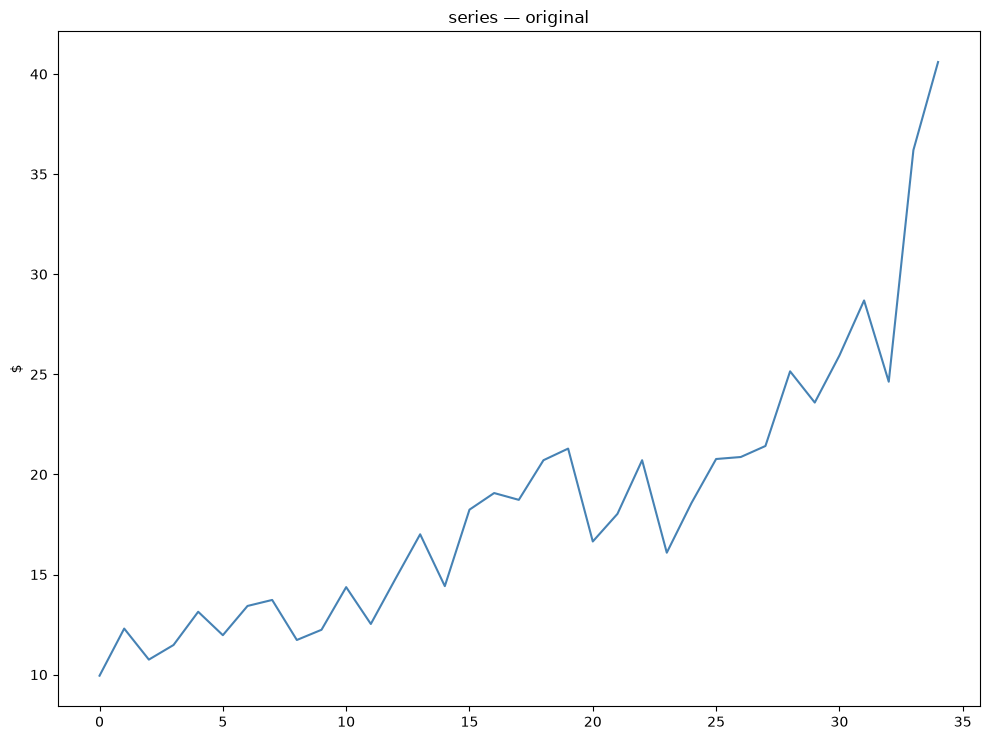

In [5]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(series, color="steelblue")
ax.set_title("series — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

In [7]:
series_diff = series.diff(1).dropna()
adf_result = adfuller(series_diff)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: 0.7944026914292845
p-value: 0.9915452776293924
Critical Values: {'1%': np.float64(-3.7529275211638033), '5%': np.float64(-2.998499866852963), '10%': np.float64(-2.6389669754253307)}


# p-value > 0.05 quiere decir que NO es estacionaria

In [8]:
series_diff = series.diff(1).diff(1).dropna()
adf_result = adfuller(series_diff)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -1.3415985143775435
p-value: 0.6099327181618867
Critical Values: {'1%': np.float64(-3.7529275211638033), '5%': np.float64(-2.998499866852963), '10%': np.float64(-2.6389669754253307)}


In [9]:
series_diff = series.diff(1).diff(1).diff(1).dropna()
adf_result = adfuller(series_diff)
adf_result
# Extract values manually from the tuple
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -3.6631580150109557
p-value: 0.0046622464977587085
Critical Values: {'1%': np.float64(-3.7377092158564813), '5%': np.float64(-2.9922162731481485), '10%': np.float64(-2.635746736111111)}


## p-value < 0.05 quiere decir que ES estacionaria

In [11]:
from statsmodels.tsa.stattools import kpss
#kpss_result =kpss(finalNew['Value'], result_object=True)
#kpss_result

# Remove 'result_object=True'
statistic, p_value, lags, critical_values = kpss(series_diff, regression='c', nlags='auto')

print(f"Test Statistic: {statistic}")
print(f"p-value: {p_value}")

Test Statistic: 0.20905509653587004
p-value: 0.1


# p-value > 0.05 quiere decir que ES estacionaria en la prueba KPSS

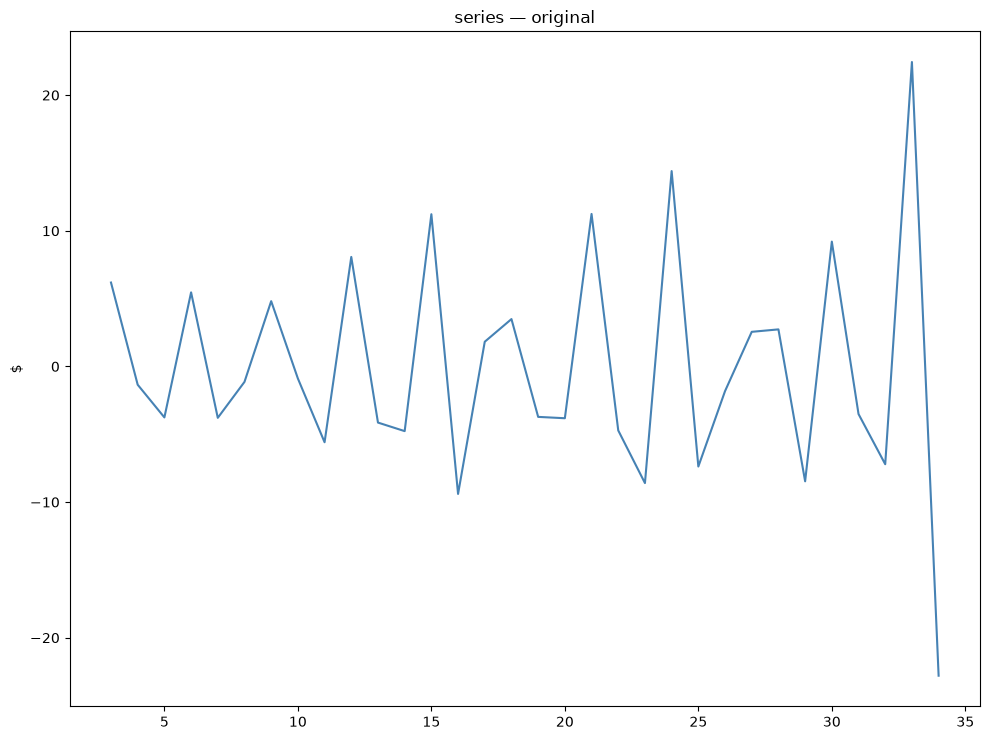

In [12]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(series_diff, color="steelblue")
ax.set_title("series — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

## Esto da d=3, D=0¶

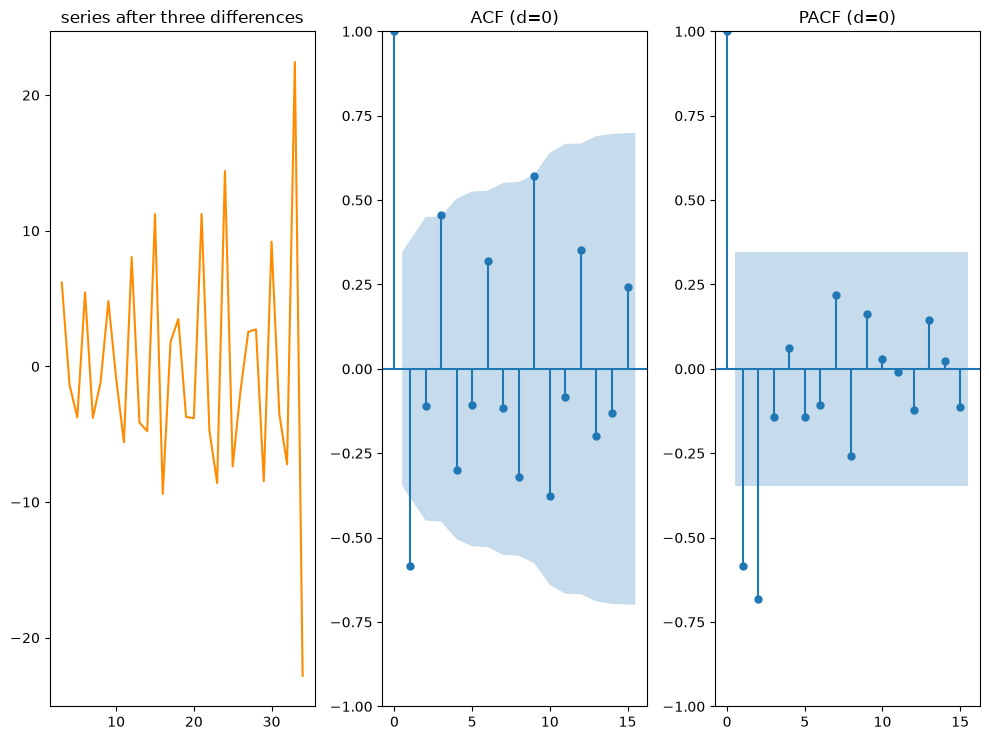

In [19]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(series_diff, color="darkorange")
axes[0].set_title("series after three differences")
plot_acf(series_diff,  ax=axes[1], lags=15, title="ACF (d=0)")
plot_pacf(series_diff, ax=axes[2], lags=15, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [20]:
!pip install pmdarima

In [22]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    series,
    seasonal=False, m=12,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='bic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=3, max_q=3, d=3, D=0, max_P=0, max_Q=0
)

print(auto_model.summary())

Performing stepwise search to minimize bic
 ARIMA(0,3,0)(0,0,0)[0]             : BIC=230.568, Time=0.01 sec
 ARIMA(1,3,0)(0,0,0)[0]             : BIC=215.542, Time=0.02 sec
 ARIMA(0,3,1)(0,0,0)[0]             : BIC=inf, Time=0.04 sec
 ARIMA(2,3,0)(0,0,0)[0]             : BIC=180.435, Time=0.04 sec
 ARIMA(3,3,0)(0,0,0)[0]             : BIC=172.170, Time=0.07 sec
 ARIMA(3,3,1)(0,0,0)[0]             : BIC=inf, Time=0.04 sec
 ARIMA(2,3,1)(0,0,0)[0]             : BIC=167.331, Time=0.04 sec
 ARIMA(1,3,1)(0,0,0)[0]             : BIC=inf, Time=0.05 sec
 ARIMA(2,3,2)(0,0,0)[0]             : BIC=170.384, Time=0.04 sec
 ARIMA(1,3,2)(0,0,0)[0]             : BIC=180.494, Time=0.03 sec
 ARIMA(3,3,2)(0,0,0)[0]             : BIC=173.556, Time=0.11 sec
 ARIMA(2,3,1)(0,0,0)[0] intercept   : BIC=inf, Time=0.09 sec

Best model:  ARIMA(2,3,1)(0,0,0)[0]          
Total fit time: 0.584 seconds
                               SARIMAX Results                                
Dep. Variable:                      y

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(series, order=(2, 3, 1),
                seasonal_order=(0, 0, 0, 0)).fit()
print(sarima_model .summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                   35
Model:               SARIMAX(2, 3, 1)   Log Likelihood                 -76.734
Date:                Sun, 04 Oct 2026   AIC                            161.468
Time:                        17:19:05   BIC                            167.331
Sample:                    01-31-2026   HQIC                           163.411
                         - 11-30-2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0542      0.117     -9.037      0.000      -1.283      -0.826
ar.L2         -0.8741      0.134     -6.501      0.000      -1.138      -0.611
ma.L1         -0.9246      0.248     -3.735      0.0

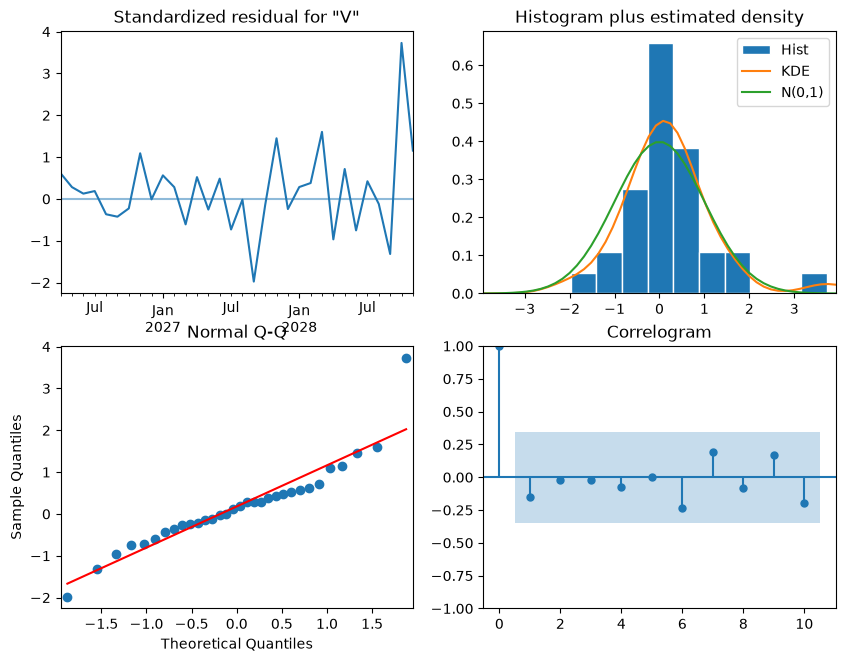

In [45]:
sarima_model.plot_diagnostics()
plt.show()

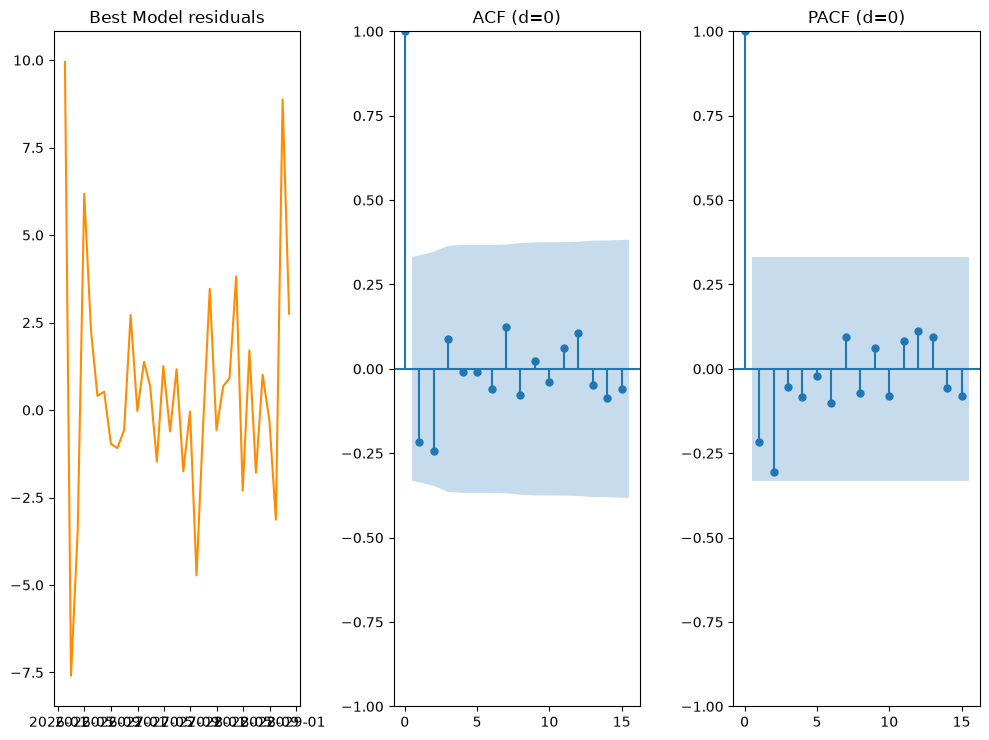

In [46]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(sarima_model.resid, color="darkorange")
axes[0].set_title("Best Model residuals")
plot_acf(sarima_model.resid,  ax=axes[1], lags=15, title="ACF (d=0)")
plot_pacf(sarima_model.resid, ax=axes[2], lags=15, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [47]:
print(acorr_ljungbox(sarima_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10], return_df=True)) # deben ser mayores a 0.05

     lb_stat  lb_pvalue
1   1.797005   0.180075
2   4.116705   0.127664
3   4.439647   0.217737
4   4.444174   0.349218
5   4.446916   0.487017
6   4.611016   0.594579
7   5.339395   0.618620
8   5.637686   0.687742
9   5.667754   0.772655
10  5.743813   0.836308


In [48]:
dates = pd.date_range(start='2026-01-01', periods=len(series), freq='M')
dates

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30', '2026-07-31', '2026-08-31',
               '2026-09-30', '2026-10-31', '2026-11-30', '2026-12-31',
               '2027-01-31', '2027-02-28', '2027-03-31', '2027-04-30',
               '2027-05-31', '2027-06-30', '2027-07-31', '2027-08-31',
               '2027-09-30', '2027-10-31', '2027-11-30', '2027-12-31',
               '2028-01-31', '2028-02-29', '2028-03-31', '2028-04-30',
               '2028-05-31', '2028-06-30', '2028-07-31', '2028-08-31',
               '2028-09-30', '2028-10-31', '2028-11-30'],
              dtype='datetime64[ns]', freq='ME')

In [49]:
series.index = dates
series.index

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30', '2026-07-31', '2026-08-31',
               '2026-09-30', '2026-10-31', '2026-11-30', '2026-12-31',
               '2027-01-31', '2027-02-28', '2027-03-31', '2027-04-30',
               '2027-05-31', '2027-06-30', '2027-07-31', '2027-08-31',
               '2027-09-30', '2027-10-31', '2027-11-30', '2027-12-31',
               '2028-01-31', '2028-02-29', '2028-03-31', '2028-04-30',
               '2028-05-31', '2028-06-30', '2028-07-31', '2028-08-31',
               '2028-09-30', '2028-10-31', '2028-11-30'],
              dtype='datetime64[ns]', freq='ME')

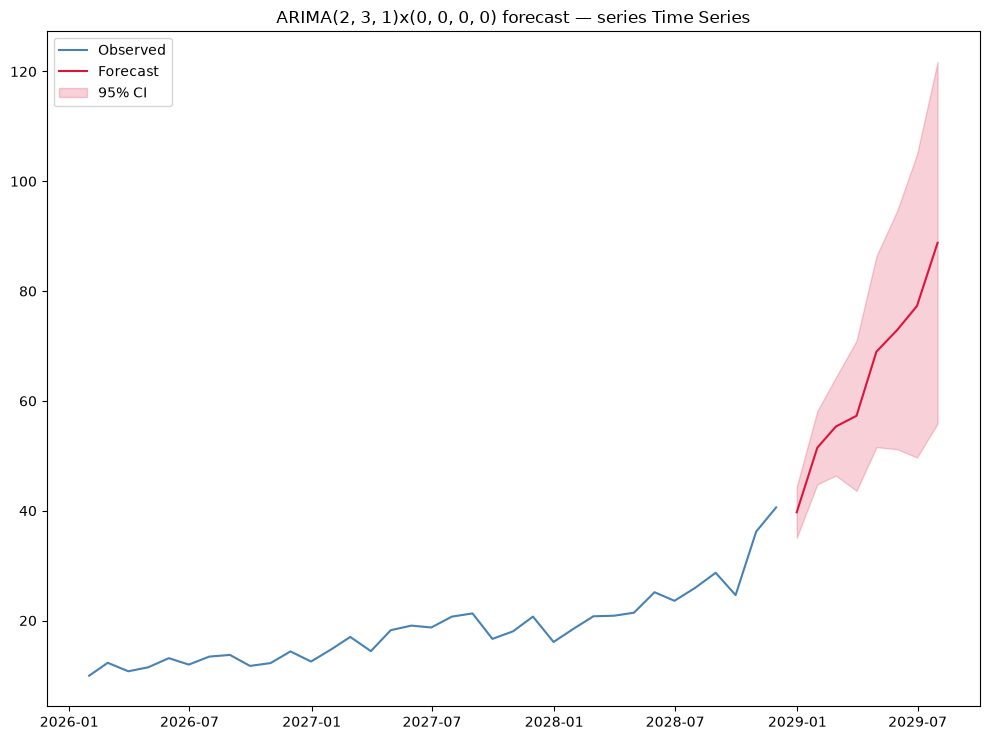

In [50]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = sarima_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(series.index[-1], periods=steps + 1, freq="M")[1:]

fig, ax = plt.subplots()
ax.plot(series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 3, 1)x(0, 0, 0, 0) forecast — series Time Series")
ax.legend(); plt.tight_layout(); plt.show()

In [51]:
series

2026-01-31     9.946
2026-02-28    12.300
2026-03-31    10.750
2026-04-30    11.480
2026-05-31    13.140
2026-06-30    11.970
2026-07-31    13.430
2026-08-31    13.730
2026-09-30    11.730
2026-10-31    12.240
2026-11-30    14.370
2026-12-31    12.530
2027-01-31    14.790
2027-02-28    17.010
2027-03-31    14.420
2027-04-30    18.240
2027-05-31    19.070
2027-06-30    18.730
2027-07-31    20.710
2027-08-31    21.290
2027-09-30    16.650
2027-10-31    18.030
2027-11-30    20.710
2027-12-31    16.090
2028-01-31    18.570
2028-02-29    20.770
2028-03-31    20.870
2028-04-30    21.420
2028-05-31    25.150
2028-06-30    23.590
2028-07-31    25.940
2028-08-31    28.690
2028-09-30    24.630
2028-10-31    36.200
2028-11-30    40.600
Freq: ME, Name: Value, dtype: float64

In [60]:
sarima_pred = sarima_model.fittedvalues[1:] ## Ajustes de SARIMA
sarima_pred

2026-02-28    19.892138
2026-03-31    14.173425
2026-04-30     5.297281
2026-05-31    10.841264
2026-06-30    11.565874
2026-07-31    12.904183
2026-08-31    14.697294
2026-09-30    12.817833
2026-10-31    12.810624
2026-11-30    11.657323
2026-12-31    12.554458
2027-01-31    13.412074
2027-02-28    16.323565
2027-03-31    15.893285
2027-04-30    16.980335
2027-05-31    19.681838
2027-06-30    17.563141
2027-07-31    22.462032
2027-08-31    21.331311
2027-09-30    21.378496
2027-10-31    18.386077
2027-11-30    17.245758
2027-12-31    16.666179
2028-01-31    17.890748
2028-02-29    19.863175
2028-03-31    17.048510
2028-04-30    23.723025
2028-05-31    23.443604
2028-06-30    25.380608
2028-07-31    24.933453
2028-08-31    28.977001
2028-09-30    27.762930
2028-10-31    27.320490
2028-11-30    37.849019
Freq: ME, dtype: float64

In [61]:
sarima_resid = sarima_model.resid[1:]
sarima_resid

2026-02-28   -7.592138
2026-03-31   -3.423425
2026-04-30    6.182719
2026-05-31    2.298736
2026-06-30    0.404126
2026-07-31    0.525817
2026-08-31   -0.967294
2026-09-30   -1.087833
2026-10-31   -0.570624
2026-11-30    2.712677
2026-12-31   -0.024458
2027-01-31    1.377926
2027-02-28    0.686435
2027-03-31   -1.473285
2027-04-30    1.259665
2027-05-31   -0.611838
2027-06-30    1.166859
2027-07-31   -1.752032
2027-08-31   -0.041311
2027-09-30   -4.728496
2027-10-31   -0.356077
2027-11-30    3.464242
2027-12-31   -0.576179
2028-01-31    0.679252
2028-02-29    0.906825
2028-03-31    3.821490
2028-04-30   -2.303025
2028-05-31    1.706396
2028-06-30   -1.790608
2028-07-31    1.006547
2028-08-31   -0.287001
2028-09-30   -3.132930
2028-10-31    8.879510
2028-11-30    2.750981
Freq: ME, dtype: float64

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date_x               35 non-null     object 
 1   Close                35 non-null     float64
 2   High                 35 non-null     float64
 3   Low                  35 non-null     float64
 4   Open                 35 non-null     float64
 5   Volume               35 non-null     int64  
 6   Close_l              35 non-null     float64
 7   Close_2              35 non-null     float64
 8   Rolling_mean_3_x     35 non-null     float64
 9   Rolling_std_3_x      35 non-null     float64
 10  Spanding_mean_x      35 non-null     float64
 11  return_x             35 non-null     float64
 12  Year_x               35 non-null     int64  
 13  Month_x              35 non-null     int64  
 14  YM                   35 non-null     object 
 15  Date_y               35 non-null     objec

## XGBoost

In [95]:
X = df[['Close','Rolling_mean_3_y']][1:]
len(X)

34

In [96]:
len(sarima_resid)

34

In [97]:
sarima_resid

2026-02-28   -7.592138
2026-03-31   -3.423425
2026-04-30    6.182719
2026-05-31    2.298736
2026-06-30    0.404126
2026-07-31    0.525817
2026-08-31   -0.967294
2026-09-30   -1.087833
2026-10-31   -0.570624
2026-11-30    2.712677
2026-12-31   -0.024458
2027-01-31    1.377926
2027-02-28    0.686435
2027-03-31   -1.473285
2027-04-30    1.259665
2027-05-31   -0.611838
2027-06-30    1.166859
2027-07-31   -1.752032
2027-08-31   -0.041311
2027-09-30   -4.728496
2027-10-31   -0.356077
2027-11-30    3.464242
2027-12-31   -0.576179
2028-01-31    0.679252
2028-02-29    0.906825
2028-03-31    3.821490
2028-04-30   -2.303025
2028-05-31    1.706396
2028-06-30   -1.790608
2028-07-31    1.006547
2028-08-31   -0.287001
2028-09-30   -3.132930
2028-10-31    8.879510
2028-11-30    2.750981
Freq: ME, dtype: float64

In [98]:
sarima_resid.loc['2026-02-28']

np.float64(-7.592138092004991)

In [99]:
y = sarima_resid

In [100]:
!pip install xgboost scikit-learn

In [101]:
from xgboost import XGBRegressor

In [102]:
xgb_model = XGBRegressor()
xgb_model.fit(X,y)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
xgb_residual_pred = xgb_model.predict(X)

In [104]:
xgb_residual_pred

array([-7.590786  , -3.4231358 ,  6.180566  ,  2.2965584 ,  0.40425918,
        0.5253676 , -0.96751994, -1.0856054 , -0.56846064,  2.710098  ,
       -0.02157398,  1.3777317 ,  0.68538034, -1.4735869 ,  1.2571455 ,
       -0.6114139 ,  1.1644067 , -1.7514699 , -0.0411982 , -4.72803   ,
       -0.3539358 ,  3.461776  , -0.5735348 ,  0.67993784,  0.908868  ,
        3.8186874 , -2.3006778 ,  1.7068533 , -1.7903581 ,  1.0052434 ,
       -0.28762937, -3.131412  ,  8.877381  ,  2.7516766 ], dtype=float32)

In [105]:
sarima_resid

2026-02-28   -7.592138
2026-03-31   -3.423425
2026-04-30    6.182719
2026-05-31    2.298736
2026-06-30    0.404126
2026-07-31    0.525817
2026-08-31   -0.967294
2026-09-30   -1.087833
2026-10-31   -0.570624
2026-11-30    2.712677
2026-12-31   -0.024458
2027-01-31    1.377926
2027-02-28    0.686435
2027-03-31   -1.473285
2027-04-30    1.259665
2027-05-31   -0.611838
2027-06-30    1.166859
2027-07-31   -1.752032
2027-08-31   -0.041311
2027-09-30   -4.728496
2027-10-31   -0.356077
2027-11-30    3.464242
2027-12-31   -0.576179
2028-01-31    0.679252
2028-02-29    0.906825
2028-03-31    3.821490
2028-04-30   -2.303025
2028-05-31    1.706396
2028-06-30   -1.790608
2028-07-31    1.006547
2028-08-31   -0.287001
2028-09-30   -3.132930
2028-10-31    8.879510
2028-11-30    2.750981
Freq: ME, dtype: float64

In [106]:
final_forecast = sarima_pred + sarima_resid

In [107]:
final_forecast

2026-02-28    12.30
2026-03-31    10.75
2026-04-30    11.48
2026-05-31    13.14
2026-06-30    11.97
2026-07-31    13.43
2026-08-31    13.73
2026-09-30    11.73
2026-10-31    12.24
2026-11-30    14.37
2026-12-31    12.53
2027-01-31    14.79
2027-02-28    17.01
2027-03-31    14.42
2027-04-30    18.24
2027-05-31    19.07
2027-06-30    18.73
2027-07-31    20.71
2027-08-31    21.29
2027-09-30    16.65
2027-10-31    18.03
2027-11-30    20.71
2027-12-31    16.09
2028-01-31    18.57
2028-02-29    20.77
2028-03-31    20.87
2028-04-30    21.42
2028-05-31    25.15
2028-06-30    23.59
2028-07-31    25.94
2028-08-31    28.69
2028-09-30    24.63
2028-10-31    36.20
2028-11-30    40.60
Freq: ME, dtype: float64

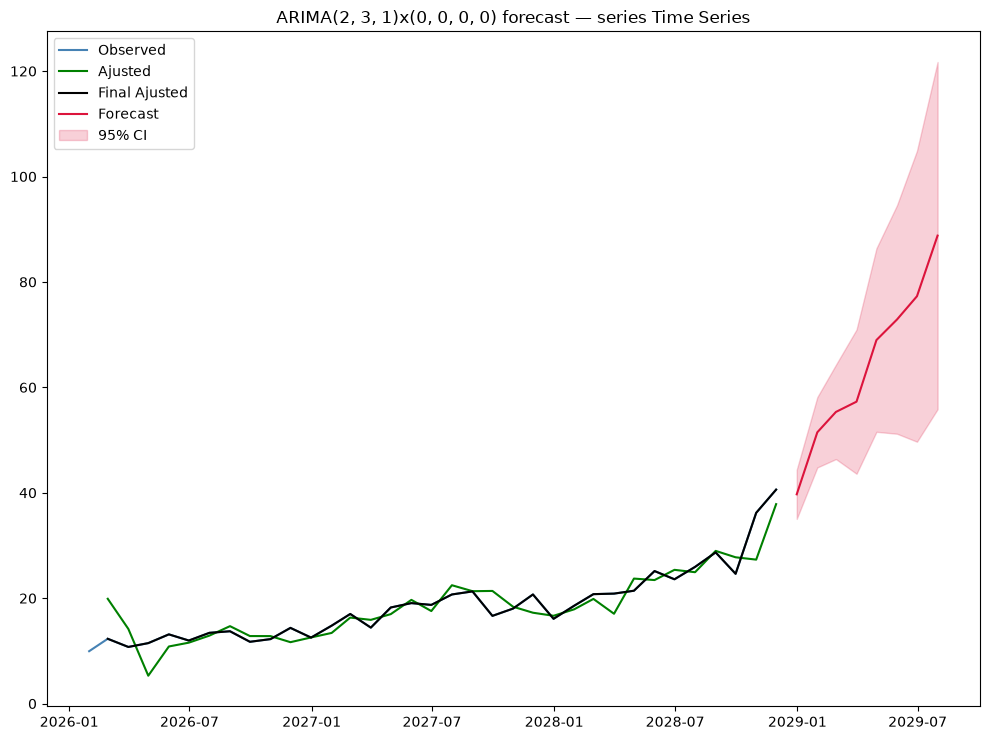

In [108]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = sarima_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(series.index[-1], periods=steps + 1, freq="M")[1:]

fig, ax = plt.subplots()
ax.plot(series, label="Observed", color="steelblue")
ax.plot(sarima_pred, label="Ajusted", color="green")
ax.plot(final_forecast, label="Final Ajusted", color="black")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 3, 1)x(0, 0, 0, 0) forecast — series Time Series")
ax.legend(); plt.tight_layout(); plt.show()

In [94]:
xgb_model.f

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None
